In [1]:
using Pkg
Pkg.activate(".")
using Distributions
using PSIS
using Plots
using PyCall
getdist = PyCall.pyimport("getdist")
plots = PyCall.pyimport("getdist.plots")
plt = PyCall.pyimport("matplotlib.pyplot")

  Activating project at `~/Desktop/Waterloo/Masters/JulaiLocalEnv`


PyObject <module 'matplotlib.pyplot' from '/opt/anaconda3/lib/python3.12/site-packages/matplotlib/pyplot.py'>

In [2]:
proposal = Normal(0,1)
theta = rand(proposal, 100000)

100000-element Vector{Float64}:
 -0.13358166404717284
  0.1530983474460774
  1.2290690942422622
 -0.63000351195139
  0.07242037068749375
  1.4518780959909046
 -1.4226130736435976
 -0.8974904864797891
  0.004539481831560021
 -0.8299242720076953
  ⋮
  0.613738537381342
 -0.4280266094739384
  0.8702077753942942
  0.6772358963732553
  0.4283480059343396
 -0.3511241412709031
 -0.19898702923831568
  0.24584308076661127
  0.5462983386195263

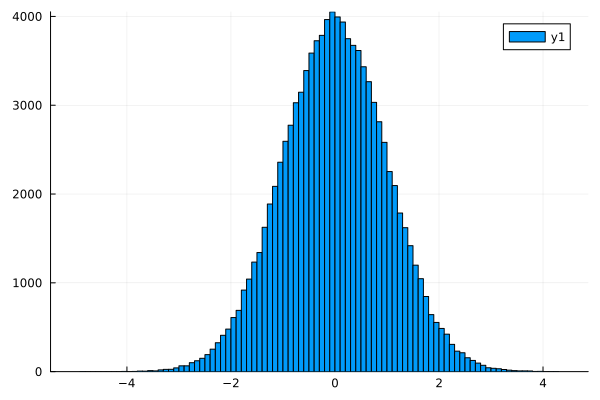

In [3]:
histogram(theta)

In [4]:
target = Normal(0.25,1)
theta_2 = rand(target, 100000);

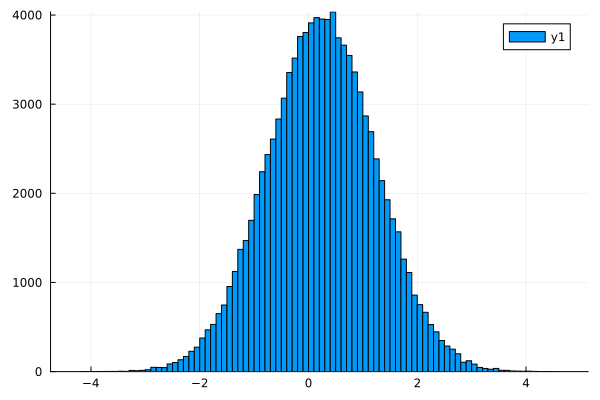

In [5]:
histogram(theta_2)

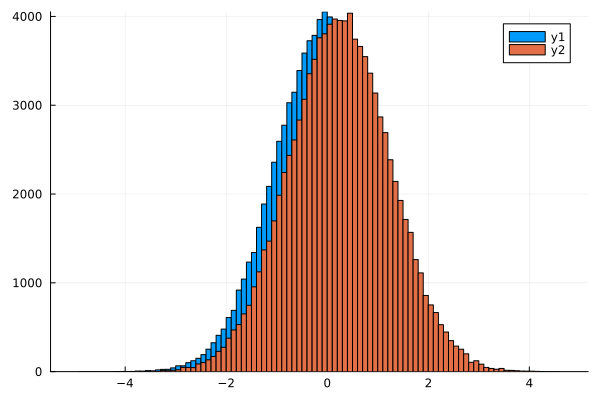

In [6]:
histogram([theta, theta_2])

In [7]:
logratios = logpdf.(target, theta) - logpdf.(proposal, theta)

100000-element Vector{Float64}:
 -0.06464541601179319
  0.0070245868615193
  0.27601727356056527
 -0.1887508779878475
 -0.013144907328126565
  0.331719523997726
 -0.3869032684108995
 -0.25562262161994753
 -0.030115129542110042
 -0.2387310680019239
  ⋮
  0.12218463434533544
 -0.1382566523684845
  0.18630194384857357
  0.1380589740933138
  0.07583700148358485
 -0.11903103531772563
 -0.08099675730957889
  0.030210770191652858
  0.10532458465488159

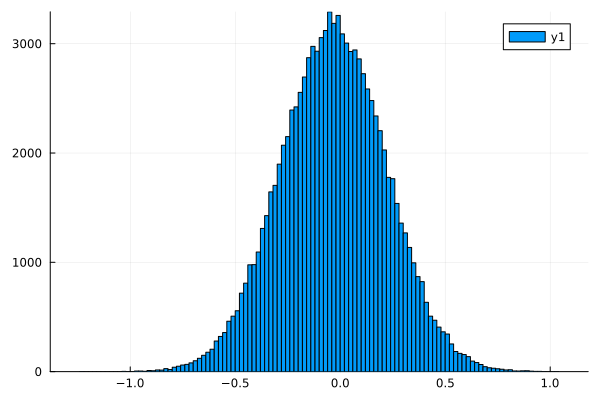

In [8]:
histogram([logratios])

In [9]:
result = psis(logratios)

PSISResult with 100000 draws, 1 chains, and 1 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good  1 (100.0%)  93907

In [10]:
result.weights

100000-element Vector{Float64}:
 9.382239706901971e-6
 1.007934733577893e-5
 1.319029324442321e-5
 8.287207388052051e-6
 9.878088465830465e-6
 1.3945870587992114e-5
 6.797539149059273e-6
 7.751150652469375e-6
 9.711869485111706e-6
 7.883191678824191e-6
 ⋮
 1.1309561966167024e-5
 8.716408404720313e-6
 1.2058452533561336e-5
 1.1490526340039936e-5
 1.0797352084782976e-5
 8.885608006482823e-6
 9.2300749426105e-6
 1.0315779316539863e-5
 1.1120480628832307e-5

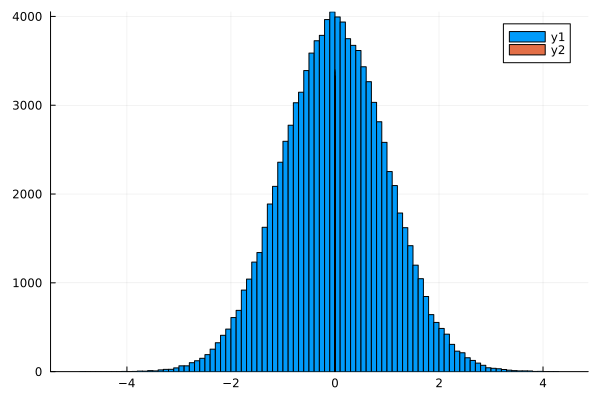

In [11]:
histogram([theta, result.weights])

In [12]:
samples = getdist.MCSamples(samples=theta)
samples_2 = getdist.MCSamples(samples=theta, weights=result.weights)
samples_3 = getdist.MCSamples(samples=theta_2)

PyObject <getdist.mcsamples.MCSamples object at 0x322d8ed50>

In [13]:
g = plots.get_subplot_plotter()
g.triangle_plot([samples, samples_2, samples_3], filled=true)
plt.savefig("pippo.pdf")

In [14]:
result.pareto_shape

-0.0043592474003157945

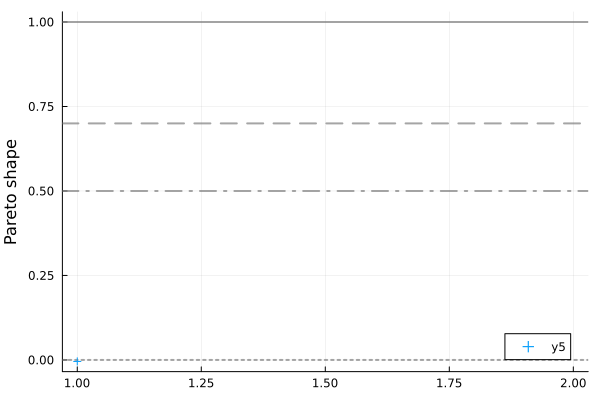

In [15]:
using Plots
plot(result; showlines=true, marker=:+, legend=true, linewidth=2)

# Marco Example

In [20]:
using PSIS, Distributions, LinearAlgebra

# 1. Setup dimensions
D = 4               # Dimensions of the multivariate distribution
ndraws = 1000
nchains = 4         # Standard MCMC usually has multiple chians

# 2. Define Multivariate Distributions# Proposal: Multivariate Normal (4D)
proposal = MvNormal(zeros(D), I)

# Target: Multivariate T-Distribution (4D) with heavy tails (df=7)
target = MvTDist(7.0, zeros(D), Matrix{Float64}(I, D, D))

# 3. Generate samples
# Distributions.jl generates multivariate samples as a (Dimension x Total_Count) matrix
total_samples = ndraws * nchains
x = rand(proposal, total_samples)

# 4. Calculate log importance ratios
# logpdf on a Multivariate distribution accepts the matrix and returns a vector of log-probabilities (one per column/sample)
log_ratios_flat = logpdf(target, x) .- logpdf(proposal, x)

# 5. Reshape for PSIS
# PSIS expects an array of shape (ndraws, nchains)
log_ratios = reshape(log_ratios_flat, ndraws, nchains)

# 6. Run PSIS
result = psis(log_ratios)

#Optional: Check the Pareto k shape values
println("Pareto k values: ", result.pareto_shape)
println("PSIS Weights: ", result.weights)

Pareto k values: 0.6100034608161673
PSIS Weights: [0.00021403787132087606 0.0002063465298524831 0.00020497082158725286 0.00021694023618701568; 0.0006245260014422559 0.0002496502940651282 0.0002201732146965354 0.00021987255536655661; 0.00042302150662875434 0.00021962396055123437 0.00022772661587780303 0.0003421434990168423; 0.00022956291290775262 0.00022858312264997042 0.0002076076495200037 0.00021168078191267692; 0.00020632376145135077 0.00021399979683372618 0.0002298775940800078 0.00028990961875862575; 0.00022304502487347866 0.00021732798086596038 0.00021490294314285434 0.00020784976594216567; 0.00020502883830101446 0.000204713806216156 0.00021228957322677684 0.0007672374353238707; 0.00021406338932619432 0.00020803519281763138 0.00020500159877511677 0.0003320492114259011; 0.00020468241800293893 0.00025628380963608766 0.0002056645112848669 0.0002790555571206671; 0.0002251391913521511 0.0002106899919363006 0.00021230794521040632 0.00020691606517212672; 0.0002212291932186095 0.0002365197

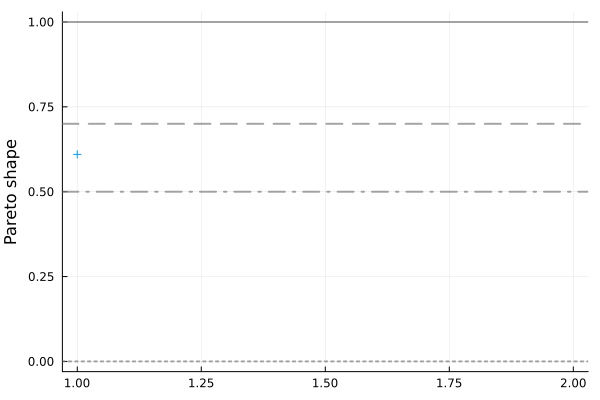

In [21]:
plot(result, showlines=true, marker=:+, legend=false, linewidth=2)

# PSIS.jl Documentation Examples

In [22]:
using PSIS, Distributions, Plots
proposal = Normal()
target = TDist(7)
ndraws, nchains, nparams = (1000, 1, 30)
x = rand(proposal, ndraws, nchains, nparams)
log_ratios = logpdf.(target, x) .- logpdf.(proposal, x)
result = psis(log_ratios)

┌ Warning: 8 parameters had Pareto shape values 0.7 < k ≤ 1. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS /Users/ethansmith/.julia/packages/PSIS/4tW5l/src/core.jl:373


PSISResult with 1000 draws, 1 chains, and 30 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good   6 (20.0%)  935
  (0.5, 0.7]  okay  16 (53.3%)  900
    (0.7, 1]  bad    8 (26.7%)  ——

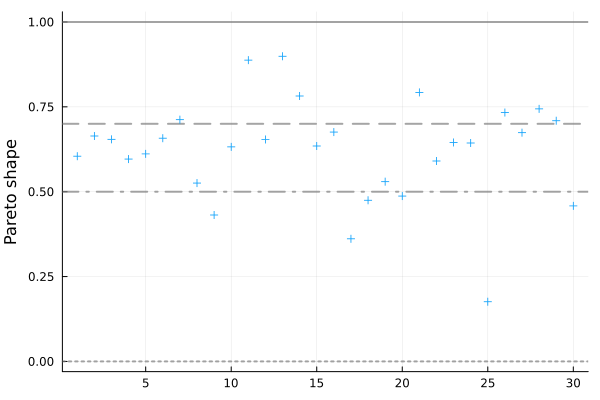

In [23]:
plot(result, showlines=true, marker=:+, legend=false, linewidth=2)

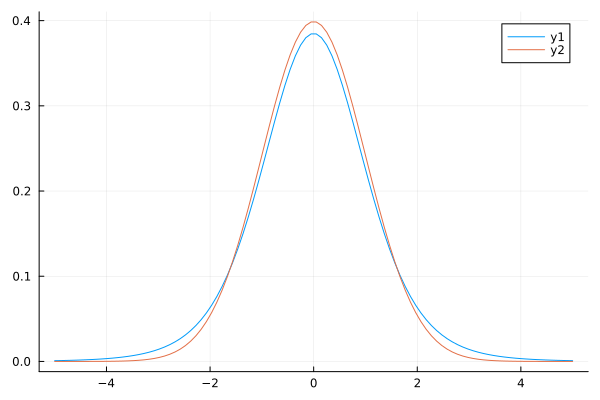

In [24]:
t = TDist(7)
proposal = Normal()

x = range(-5, 5, length = 100)
y = pdf.(t, x)
z = pdf.(proposal, x)

plot(x, [y,z])

# Comparing a Single Example to a Multiple Parameter Example 

In [25]:
using PSIS, Distributions, LinearAlgebra

# 1. Setup dimensions
D = 4               # Dimensions of the multivariate distribution
ndraws = 2
nchains = 3         # Standard MCMC usually has multiple chians

# 2. Define Multivariate Distributions# Proposal: Multivariate Normal (4D)
proposal = MvNormal(zeros(D), I)

total_samples = ndraws * nchains

x = rand(proposal, total_samples)

x


4×6 Matrix{Float64}:
 -0.167518   -0.962616  -1.43605    0.0984781  -1.14645   -1.13322
 -0.908289   -1.01975   -0.440508   0.920822   -1.17449   -0.15169
  0.0155406   0.317326   1.25999    0.930801   -0.573736   0.848359
  1.5381      1.09316    0.524278  -1.91817     1.12206    0.943816